In [1]:
from pathlib import Path
import polars as pl
from itertools import product
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use(hep.style.ATLAS)

from utils import add_project_root_to_sys_path
add_project_root_to_sys_path()
from neuralnet.workflows.ringer.inference import RingerCommitteeInferenceJob
from neuralnet.bins import VariableBin, AbsoluteVariableBin
from neuralnet.plotting import quadrant_plot
from neuralnet.datasets import ParquetDataset
from neuralnet import get_logger
logger = get_logger()

2026-08-28 09:01:41.635572: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-28 09:01:41.637534: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-28 09:01:41.731376: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-28 09:01:43.123195: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [2]:
inference_jobs = {
    'ref': {
        'path': "/home/lucasbanunes/data/neuralnet_jobs/sbrt_new/mlp_v0/threshold_fit_inference",
        'job': None,
        'label': "FP",
        'color': "C0",
        'marker': "o",
    },
    'candidate': {
        'path': "/home/lucasbanunes/data/neuralnet_jobs/sbrt_new/qat_mlp_v1/threshold_fit_inference",
        'job': None,
        'label': "QAT",
        'color': "C1",
        'marker': "^",
    }
}
output_dir = Path('quadrant_plot')

In [3]:
output_dir.mkdir(parents=True, exist_ok=True)
for value in inference_jobs.values():
    value['job'] = RingerCommitteeInferenceJob.load(value['path'])
inference_jobs

{'ref': {'path': '/home/lucasbanunes/data/neuralnet_jobs/sbrt_new/mlp_v0/threshold_fit_inference',
  'job': RingerCommitteeInferenceJob(job_path=PosixPath('/home/lucasbanunes/data/neuralnet_jobs/sbrt_new/mlp_v0/threshold_fit'), dataset_dir=PosixPath('/home/lucasbanunes/data/ringer-datasets/datasets/mc21_isabela_qt_2sigma_restriction'), output_path=PosixPath('/home/lucasbanunes/data/neuralnet_jobs/sbrt_new/mlp_v0/threshold_fit_inference'), max_rows_per_file=1000000, op_points=None, batch_size=2048, logger_name=None, data_table=None, kfold_table=None, label_col=None, fold_col=None, rings_col=None, et_col=None, eta_col=None),
  'label': 'FP',
  'color': 'C0',
  'marker': 'o'},
 'candidate': {'path': '/home/lucasbanunes/data/neuralnet_jobs/sbrt_new/qat_mlp_v1/threshold_fit_inference',
  'job': RingerCommitteeInferenceJob(job_path=PosixPath('/home/lucasbanunes/data/neuralnet_jobs/sbrt_new/qat_mlp_v1/threshold_fit'), dataset_dir=PosixPath('/home/lucasbanunes/data/ringer-datasets/datasets/mc2

In [4]:
dataset = ParquetDataset(dataset_dir=inference_jobs['ref']['job'].dataset_dir)
analysis_df = (
    dataset.get_dataframe('electron_ringer')
    .join(dataset.get_dataframe('standard_binning_kfold'), on='id', how='left')
)
for key, value in inference_jobs.items():
    inference_df = pl.scan_parquet(value['job'].inference_results_path)
    inference_df = inference_df.rename({col: f'{key}.{col}' for col in inference_df.columns if col != 'id'})
    analysis_df = (
        analysis_df
        .join(inference_df, on='id', how='left')
    )
analysis_df.collect_schema()

/tmp/ipykernel_169547/483200426.py:8: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  inference_df = inference_df.rename({col: f'{key}.{col}' for col in inference_df.columns if col != 'id'})


Schema([('id', UInt64),
        ('target', UInt8),
        ('DNNElectronTriggerContainer.tight', Boolean),
        ('DNNElectronTriggerContainer.medium', Boolean),
        ('DNNElectronTriggerContainer.loose', Boolean),
        ('ElectronContainer.calo_cluster.et', Float32),
        ('ElectronContainer.calo_cluster.eta', Float32),
        ('ElectronContainer.calo_cluster.phi', Float32),
        ('ElectronContainer.calo_cluster.etaBE2', Float32),
        ('ElectronContainer.calo_cluster.energy', Float32),
        ('ElectronContainer.et', Float32),
        ('ElectronContainer.eta', Float32),
        ('ElectronContainer.phi', Float32),
        ('ElectronContainer.reta', Float32),
        ('ElectronContainer.eratio', Float32),
        ('ElectronContainer.weta1', Float32),
        ('ElectronContainer.weta2', Float32),
        ('ElectronContainer.rhad', Float32),
        ('ElectronContainer.rhad1', Float32),
        ('ElectronContainer.rphi', Float32),
        ('ElectronContainer.f1', Float3

In [5]:
is_electron = pl.col("label")
is_jet = ~pl.col('label')

def get_bin_filter(
    et_bin, eta_bin
):
    return (
        pl.col("ElectronContainer.eta").is_between(et_bin.get('low'), et_bin.get('high'), closed="left") &
        pl.col("ElectronContainer.eta").abs().is_between(eta_bin.get('low'), eta_bin.get('high'), closed="left")
    )

In [6]:
et_bins = [
    VariableBin(low=15000.0, high=20000.0, closed="left", var_name="TrigEMClusterContainer.et", label="$E_T^{{FastCalo}} \\; MeV$"),
    VariableBin(low=20000.0, high=30000.0, closed="left", var_name="TrigEMClusterContainer.et", label="$E_T^{{FastCalo}} \\; MeV$"),
    VariableBin(low=30000.0, high=40000.0, closed="left", var_name="TrigEMClusterContainer.et", label="$E_T^{{FastCalo}} \\; MeV$"),
    VariableBin(low=40000.0, high=50000.0, closed="left", var_name="TrigEMClusterContainer.et", label="$E_T^{{FastCalo}} \\; MeV$"),
    VariableBin(low=50000.0, high=float("inf"), closed="left", var_name="TrigEMClusterContainer.et", label="$E_T^{{FastCalo}} \\; MeV$"),
    VariableBin(low=0, high=float("inf"), closed="left", var_name="TrigEMClusterContainer.et", label="$E_T^{{FastCalo}} \\; MeV$"),
]

eta_bins = [
    AbsoluteVariableBin(low=0.0, high=0.8, closed="left", var_name="TrigEMClusterContainer.eta", label="$\\eta^{{FastCalo}}$"),
    AbsoluteVariableBin(low=0.8, high=1.37, closed="left", var_name="TrigEMClusterContainer.eta", label="$\\eta^{{FastCalo}}$"),
    AbsoluteVariableBin(low=1.37, high=1.52, closed="left", var_name="TrigEMClusterContainer.eta", label="$\\eta^{{FastCalo}}$"),
    AbsoluteVariableBin(low=1.52, high=2.37, closed="left", var_name="TrigEMClusterContainer.eta", label="$\\eta^{{FastCalo}}$"),
    AbsoluteVariableBin(low=2.37, high=2.5, closed="both", var_name="TrigEMClusterContainer.eta", label="$\\eta^{{FastCalo}}$"),
    AbsoluteVariableBin(low=0, high=2.5, closed="both", var_name="TrigEMClusterContainer.eta", label="$\\eta^{{FastCalo}}$"),
]

In [7]:
VARIABLES = {
    'fastcalo_reta':{
        'is_valid': lambda df: df.filter(pl.col("TrigEMClusterContainer.reta").is_not_null() & pl.col("TrigEMClusterContainer.reta").is_between(-0.1, 1.1, closed="both")),
        'col': "TrigEMClusterContainer.reta",
        'label': "$R_{\\eta}^{FastCalo}$"
    },
    'offline_reta': {
        'is_valid': lambda df: df.filter(pl.col("ElectronContainer.reta").is_not_null() & pl.col("ElectronContainer.reta").is_between(-0.1, 1.1, closed="both")),
        'col': "ElectronContainer.reta",
        'label': "$R_{\\eta}^{Offline}$"
    },
    'offline_rphi': {
        'is_valid': lambda df: df.filter(pl.col("ElectronContainer.rphi").is_not_null() & pl.col("ElectronContainer.rphi").is_between(-0.1, 1.1, closed="both")),
        'col': "ElectronContainer.rphi",
        'label': "$R_{\\phi}^{Offline}$"
    },
    'offline_eratio': {
        'is_valid': lambda df: df.filter(pl.col("ElectronContainer.eratio").is_not_null() & pl.col("ElectronContainer.eratio").is_between(-0.1, 1.1, closed="both")),
        'col': "ElectronContainer.eratio",
        'label': "$E_{{ratio}}^{{Offline}}$"
    },
    'offline_rhad': {
        'is_valid': lambda df: df.filter(pl.col("ElectronContainer.rhad").is_not_null() & pl.col("ElectronContainer.rhad").is_between(-0.1, 1.1, closed="both")),
        'col': "ElectronContainer.rhad",
        'label': "$R_{{had}}^{Offline}$"
    },
    'offline_f1': {
        'is_valid': lambda df: df.filter(pl.col("ElectronContainer.f1").is_not_null() & pl.col("ElectronContainer.f1").is_between(-0.1, 1.1, closed="both")),
        'col': "ElectronContainer.f1",
        'label': "$f_1^{Offline}$"
    },
    'offline_f3': {
        'is_valid': lambda df: df.filter(pl.col("ElectronContainer.f3").is_not_null() & pl.col("ElectronContainer.f3").is_between(-0.1, 1.1, closed="both")),
        'col': "ElectronContainer.f3",
        'label': "$f_3^{Offline}$"
    },
    'offline_wtots1': {
        'is_valid': lambda df: df.filter(pl.col("ElectronContainer.wtots1").is_not_null() & pl.col("ElectronContainer.wtots1").is_between(-0.1, 1.1, closed="both")),
        'col': "ElectronContainer.wtots1",
        'label': "$w_{\\text{tots}1}^{Offline}$"
    },
    'offline_weta2': {
        'is_valid': lambda df: df.filter(pl.col("ElectronContainer.weta2").is_not_null() & pl.col("ElectronContainer.weta2").is_between(-0.1, 1.1, closed="both")),
        'col': "ElectronContainer.weta2",
        'label': "$w_{\\eta 2}^{Offline}$"
    },
}
OP_POINTS = {
    'tight': {
        'label': 'Tight'
    },
    'medium': {
        'label': 'Medium'
    },
    'loose': {
        'label': 'Loose'
    },
    'very_loose': {
        'label': 'Very Loose'
    }
}

 [Fri, 28 Aug 2026 09:01:44] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:01:44] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:01:45] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:01:45] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:01:46] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:01:46] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:01:46] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:01:46] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:01:48] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:01:48] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:01:48] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:01:48] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:01:49] INFO Substituting symbo

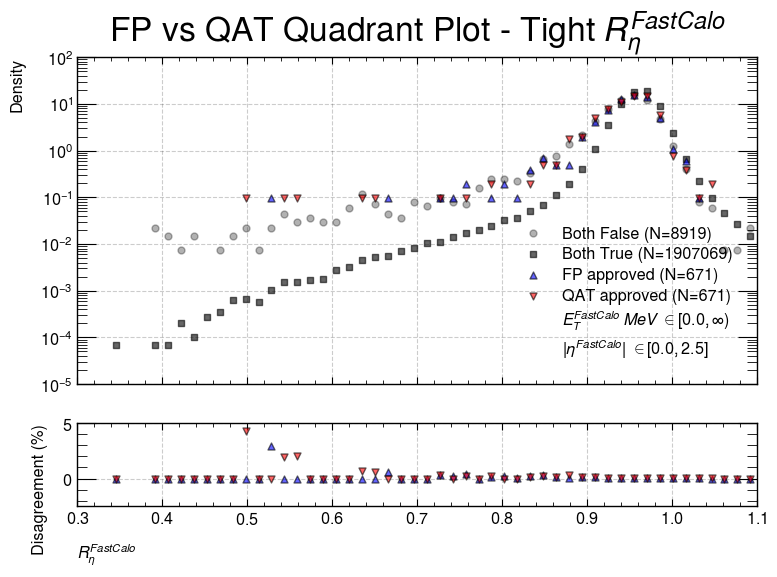

 [Fri, 28 Aug 2026 09:01:59] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:01:59] INFO Substituting symbol \in from Computer Modern


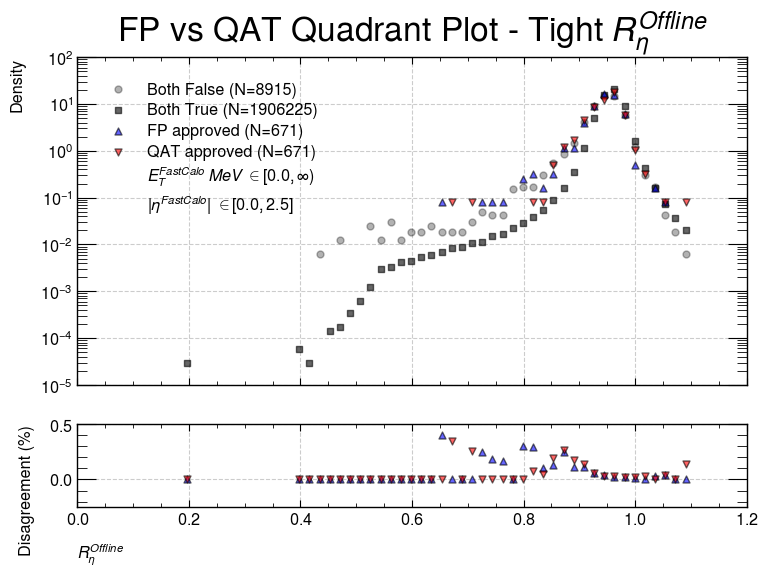

 [Fri, 28 Aug 2026 09:01:59] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:01:59] INFO Substituting symbol \in from Computer Modern


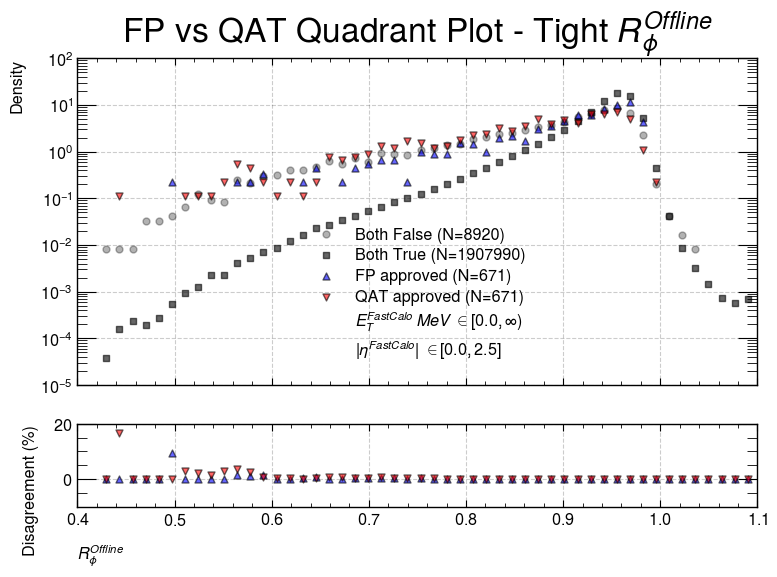

 [Fri, 28 Aug 2026 09:02:00] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:02:00] INFO Substituting symbol \in from Computer Modern


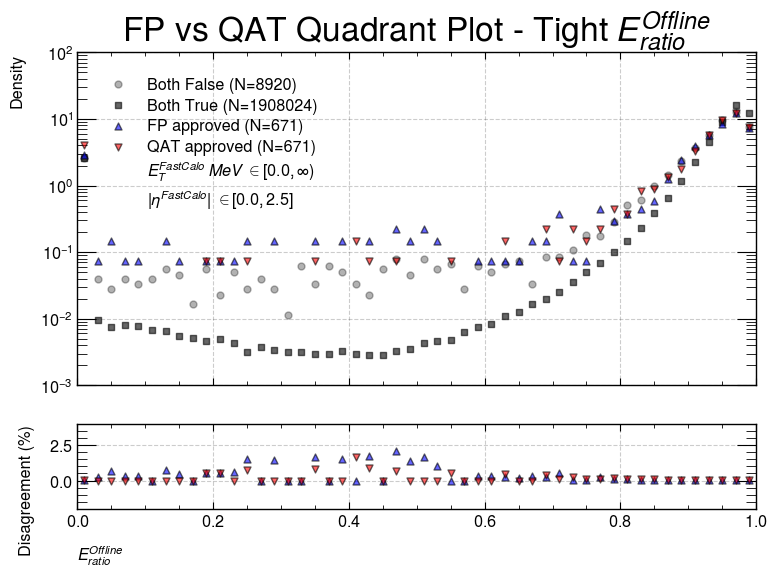

 [Fri, 28 Aug 2026 09:02:00] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:02:00] INFO Substituting symbol \in from Computer Modern


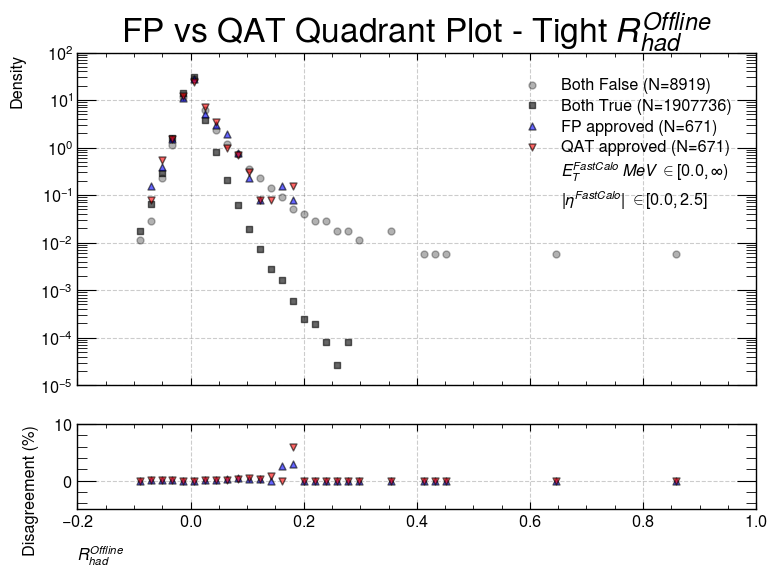

 [Fri, 28 Aug 2026 09:02:00] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:02:00] INFO Substituting symbol \in from Computer Modern


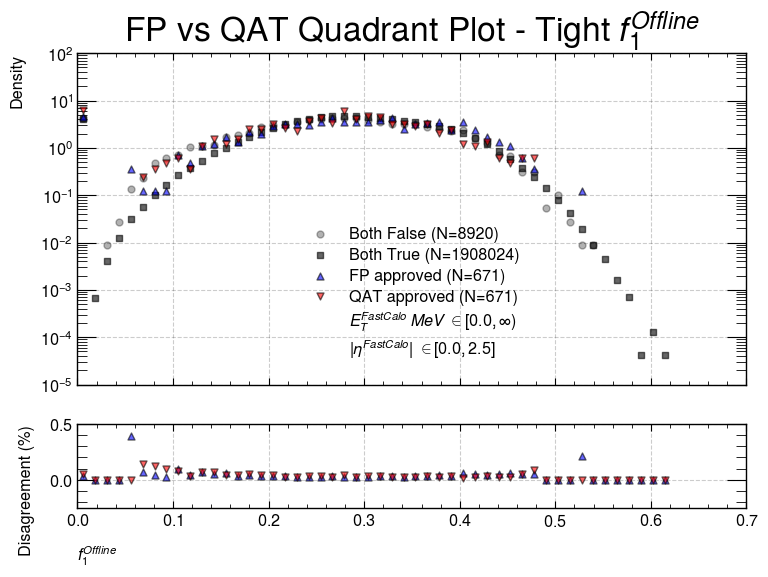

 [Fri, 28 Aug 2026 09:02:01] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:02:01] INFO Substituting symbol \in from Computer Modern


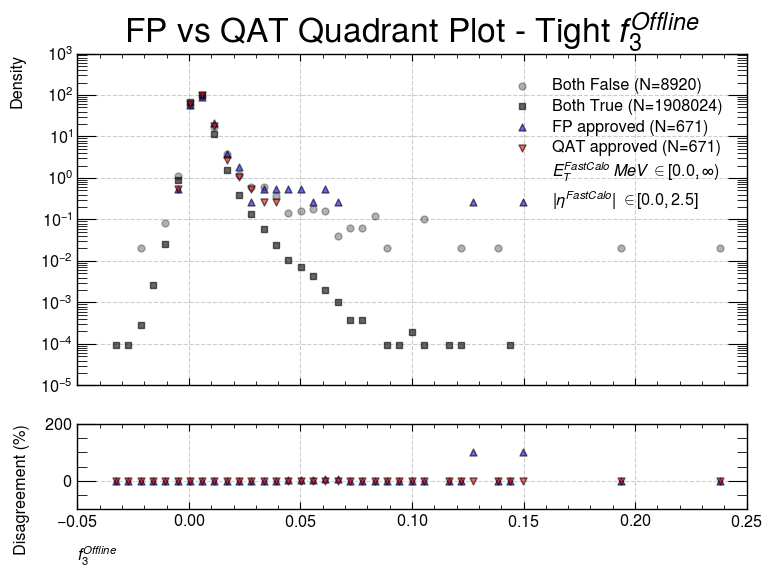

 [Fri, 28 Aug 2026 09:02:01] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:02:01] INFO Substituting symbol \in from Computer Modern


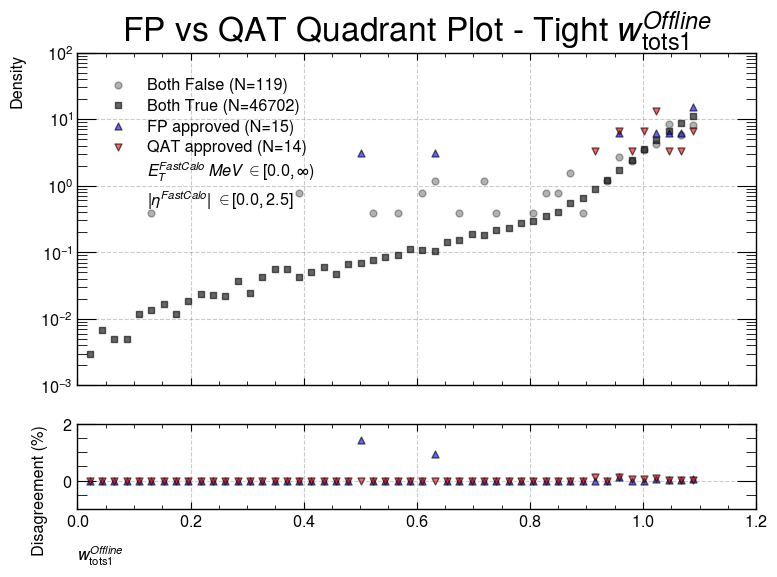

 [Fri, 28 Aug 2026 09:02:01] INFO Substituting symbol \in from Computer Modern
 [Fri, 28 Aug 2026 09:02:01] INFO Substituting symbol \in from Computer Modern


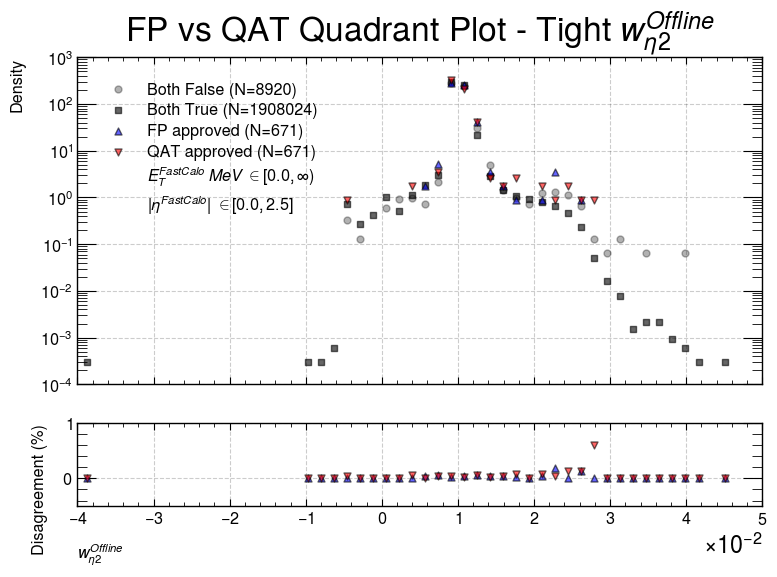

In [8]:
iterable = product(
    list(OP_POINTS.items())[:1],
    VARIABLES.items(),
    product(et_bins[-1:], eta_bins[-1:]))
for (op_point, op_point_config), (variable, variable_config), (et_bin, eta_bin) in iterable:
    plot_df = (
        analysis_df
        .filter(is_electron)
        .pipe(et_bin.is_inside_polars)
        .pipe(eta_bin.is_inside_polars)
        .pipe(variable_config['is_valid'])
    )
    fig, top_ax, bottom_ax, _ = quadrant_plot(
        plot_df,
        model_a_col={
            'col': f"ref.{op_point}.prediction",
            'label': inference_jobs['ref']['label'],
        },
        model_b_col={
            'col': f"candidate.{op_point}.prediction",
            'label': inference_jobs['candidate']['label'],
        },
        variable_col={
            'col': variable_config['col'],
            'label': variable_config['label'],
        },
        quadrant_config={
            'both_false': {
                'markersize': 25
            },
            'both_true': {
                'markersize': 25
            },
            'a_only': {
                'markersize': 25
            },
            'b_only': {
                'markersize': 25
            },
        },
        density=True,
        scatter=True,
        bins=variable_config.get('bins', 50)
    )
    top_ax.set_title(f"{inference_jobs['ref']['label']} vs {inference_jobs['candidate']['label']} Quadrant Plot - {op_point_config['label']} {variable_config['label']}")
    top_ax.plot([], [], ' ', label=f"{et_bin.as_latex()}")
    top_ax.plot([], [], ' ', label=f"{eta_bin.as_latex()}")
    top_ax.legend(loc='best', fontsize='small')
    top_ax.set_yscale("log")
    fig.tight_layout()
    fig.savefig(output_dir / f"quadrant_plot_{inference_jobs['ref']['label']}vs{inference_jobs['candidate']['label']}_{op_point}_{variable}.png", dpi=300)